In [1]:
import pandas as pd
df = pd.read_csv('c:/data/time/passengers.csv', index_col='Month')
df

,Passengers
Month,
Jan-49,112
Feb-49,118
Mar-49,132
Apr-49,129
May-49,121
...,...
Aug-60,606
Sep-60,508
Oct-60,461


<Axes: xlabel='Month'>

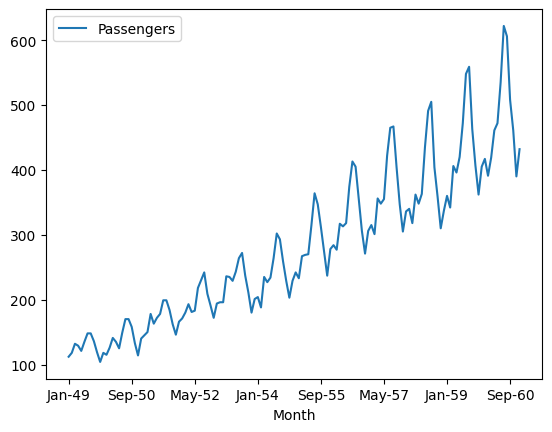

In [2]:
df.plot()

In [3]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [4]:
dataset = df.astype('float32')

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(dataset)

In [6]:
train_size = int(len(scaled) * 0.8)
test_size = len(scaled) - train_size
train, test = scaled[0:train_size, :], scaled[train_size:len(scaled),:]
print(len(train), len(test))

115 29


In [7]:
import numpy as np
def create_dataset(dataset, timestep):
    print(len(dataset), timestep)
    dataX, dataY = [],[]
    for i in range(len(dataset)-timestep):
        a = dataset[i:(i+timestep), 0]
        dataX.append(a)
        dataY.append(dataset[i + timestep, 0])
    return np.array(dataX), np.array(dataY)

In [8]:
timestep =2
X_train, y_train = create_dataset(train, timestep)
X_test, y_test = create_dataset(test, timestep)

115 2
29 2


In [9]:
#RNN 계열은 입력 형태가 보통 3차원->(샘플 수, 시간길이(timestep), 특성 수)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(113, 2, 1) (113,) (27, 2, 1) (27,)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
np.random.seed(0)
model = Sequential()
model.add(SimpleRNN(units=20, input_shape=(timestep,1)))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(loss='mse', optimizer='sgd')
model.summary()

C:\python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 20)             │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 661 (2.58 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1017  
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0459 
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0259 
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0172
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0135 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 0.0112  
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 0.0097  
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0087 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0080 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0075 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0072 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 0.0069  
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 0.0066  
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0064 
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0062
Epoch 16/100
4/4 ━━━

In [12]:
from sklearn.metrics import mean_squared_error
trainPredict = model.predict(X_train)
testPredict = model.predict(X_test)

trainPredict = scaler.inverse_transform(trainPredict)
y_train = scaler.inverse_transform([y_train])

testPredict = scaler.inverse_transform(testPredict)
y_test = scaler.inverse_transform([y_test])

trainScore = np.sqrt(mean_squared_error(y_train[0], trainPredict[:,0]))
print(trainScore)
testScore = np.sqrt(mean_squared_error(y_test[0], testPredict[:,0]))
print(testScore)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
28.52211493442309
67.75072579003604


In [13]:
from matplotlib import pyplot as plt

trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:,:] = np.nan
trainPredictPlot[timestep:len(trainPredict)+timestep,:] = trainPredict

testPredictPlot = np.empty_like(dataset)
testPredictPlot[:,:] = np.nan
# testPredictPlot[len(trainPredict)+(timestep*2)+1:len(scaled)-1,:] = testPredict
test_start = train_size + timestep
testPredictPlot[test_start:test_start + len(testPredict), :] = testPredict

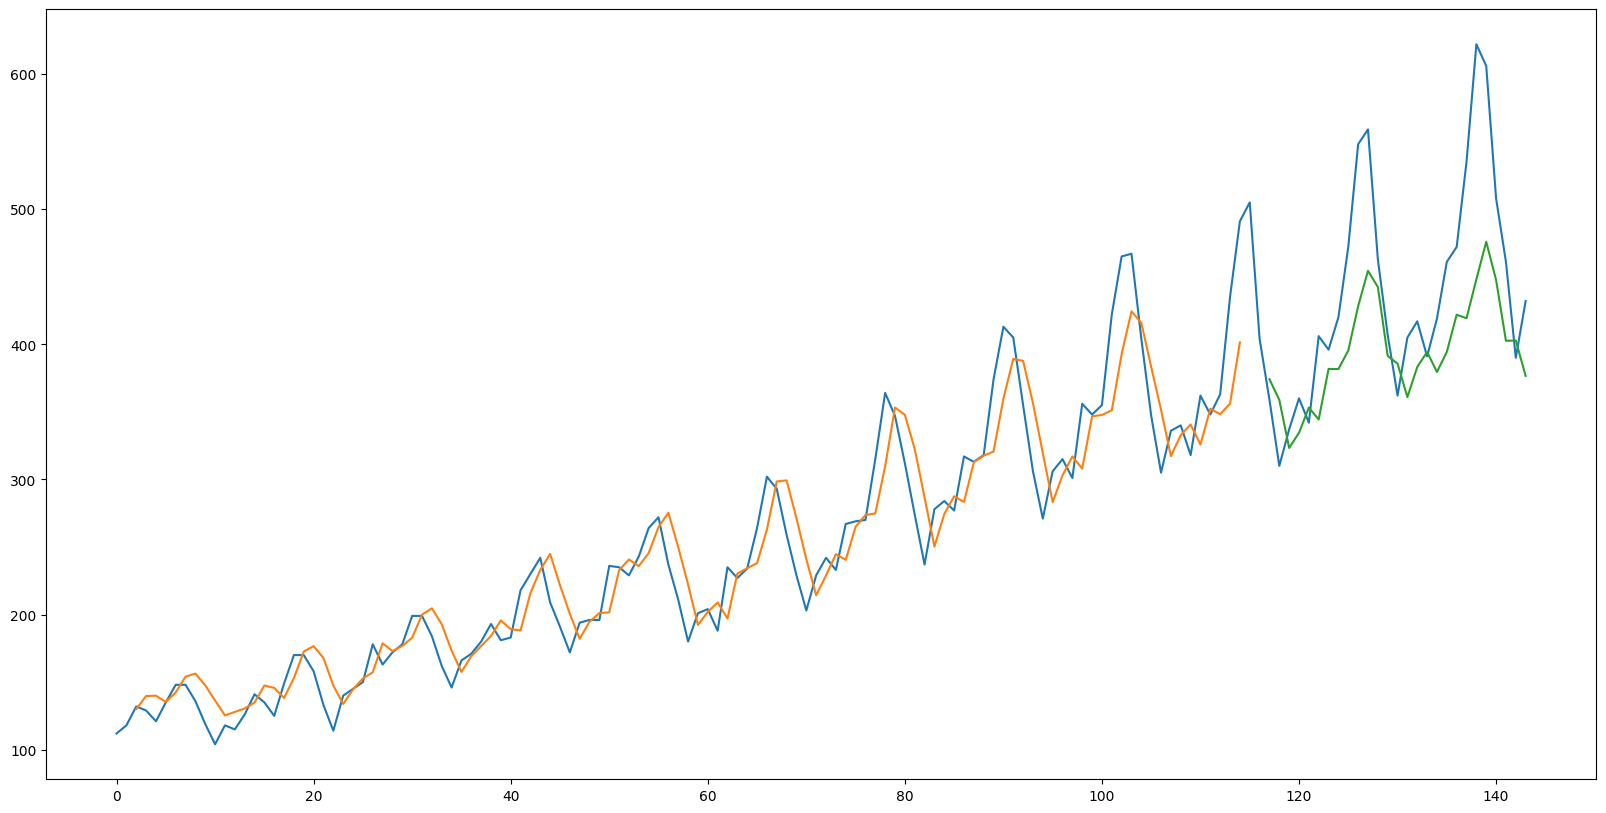

In [14]:
plt.figure(figsize=(20,10))
plt.plot(scaler.inverse_transform(scaled),label='real')
plt.plot(trainPredictPlot, label='train')
plt.plot(testPredictPlot, label='test')
plt.show()

In [15]:
trainPredict.shape

(113, 1)

In [16]:
testPredict.shape

(27, 1)